# TASK 3: DATA VISUALIZATION

## Requirements for data visualiztion ##
* Transforming the Raw data into-charts,graphs,and dashboards.
* using tools like MATPLOTLIB,sEABORN.
* Design visuals to enhance understandiing and reveal insights clearly.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("healthcare_dataset.csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54855,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
54856,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
54857,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
54858,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [5]:
# --- SETUP ---
sns.set_theme(style="whitegrid")
COLORS = ["#003366", "#2CA02C", "#D62728", "#FF7F0E", "#9467BD"]

In [8]:
df.columns = df.columns.str.strip()
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], dayfirst=False, errors='coerce')
df['Billing Amount'] = pd.to_numeric(df['Billing Amount'], errors='coerce')
df['Year'] = df['Date of Admission'].dt.year

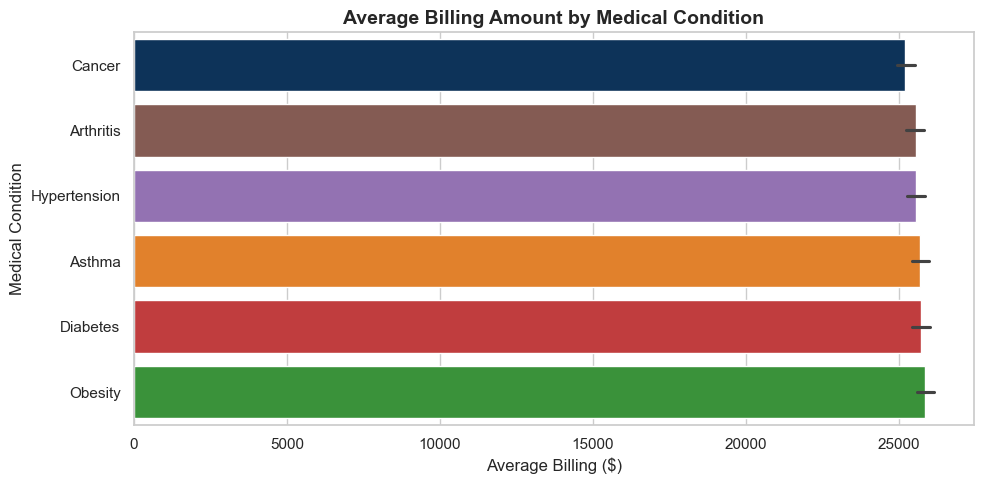

In [15]:
 #Fixed - 6 colors for 6 conditions
COLORS_6 = ["#003366", "#2CA02C", "#D62728", "#FF7F0E", "#9467BD", "#8C564B"]

plt.figure(figsize=(10, 5))
order = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values().index

# No warning now
sns.barplot(data=df, y='Medical Condition', x='Billing Amount', 
            order=order, hue='Medical Condition', palette=COLORS_6, legend=False, estimator='mean')

plt.title('Average Billing Amount by Medical Condition', fontweight='bold', fontsize=14)
plt.xlabel('Average Billing ($)')
plt.tight_layout()
plt.savefig('01_Billing_Analysis_by_Condition.png', dpi=300, bbox_inches='tight')
plt.show()


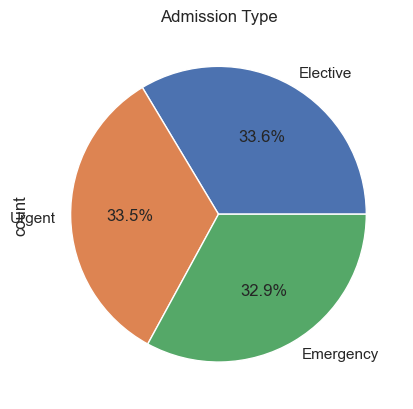

In [16]:
#  ADMISSION TYPE;
df['Admission Type'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Admission Type')
plt.savefig('02_Admission_Type.png',dpi=300)
plt.show()

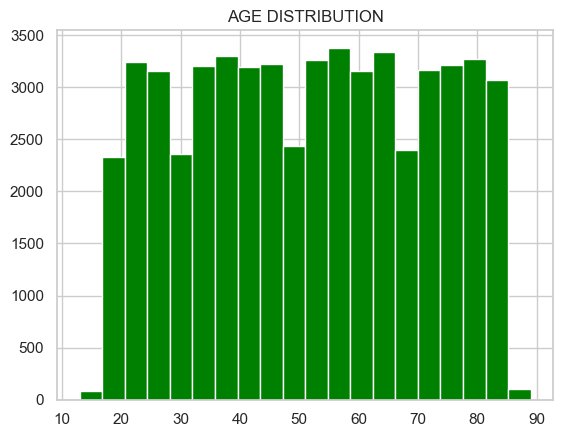

In [19]:
# AGE DISTRIBUTION
df['Age'].hist(bins=20,color = 'green')
plt.title('AGE DISTRIBUTION')
plt.savefig('03_Age_Distribution.png',dpi=300)
plt.show()

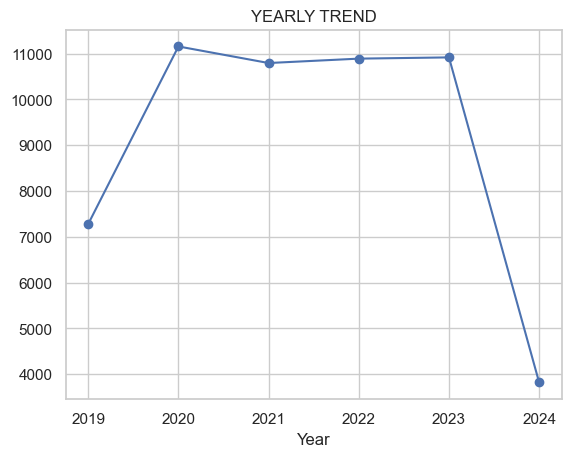

In [21]:
# YEARLY TREND
df['Year'].value_counts().sort_index().plot(marker='o')
plt.title('YEARLY TREND')
plt.savefig('04_Yearly_Trend.png',dpi=300)
plt.show()

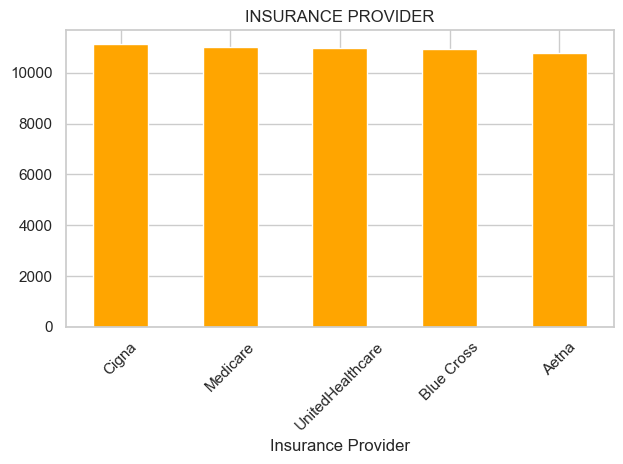

In [22]:
# INSURANCE PROVIDER
df['Insurance Provider'].value_counts().plot(kind='bar',color='orange')
plt.title('INSURANCE PROVIDER')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('05_Insurance_Provider.png',dpi=300)
plt.show()

<Figure size 1000x500 with 0 Axes>

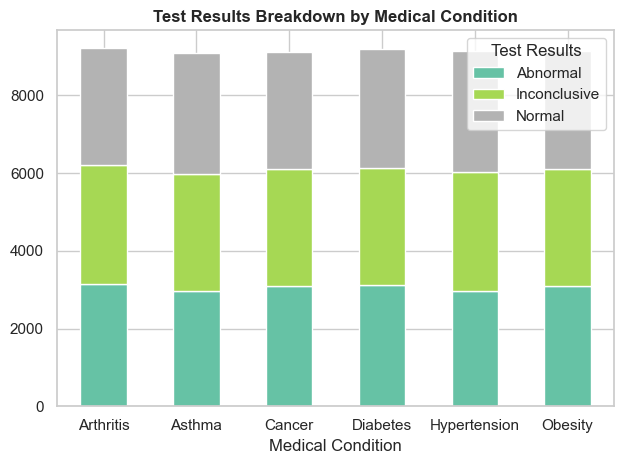

In [24]:
# --- CHART 6: TEST RESULTS ---
plt.figure(figsize=(10, 5))
pd.crosstab(df['Medical Condition'], df['Test Results']).plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Test Results Breakdown by Medical Condition', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('06_Medical_Test_Results_Breakdown.png', dpi=300, bbox_inches='tight')
plt.show()


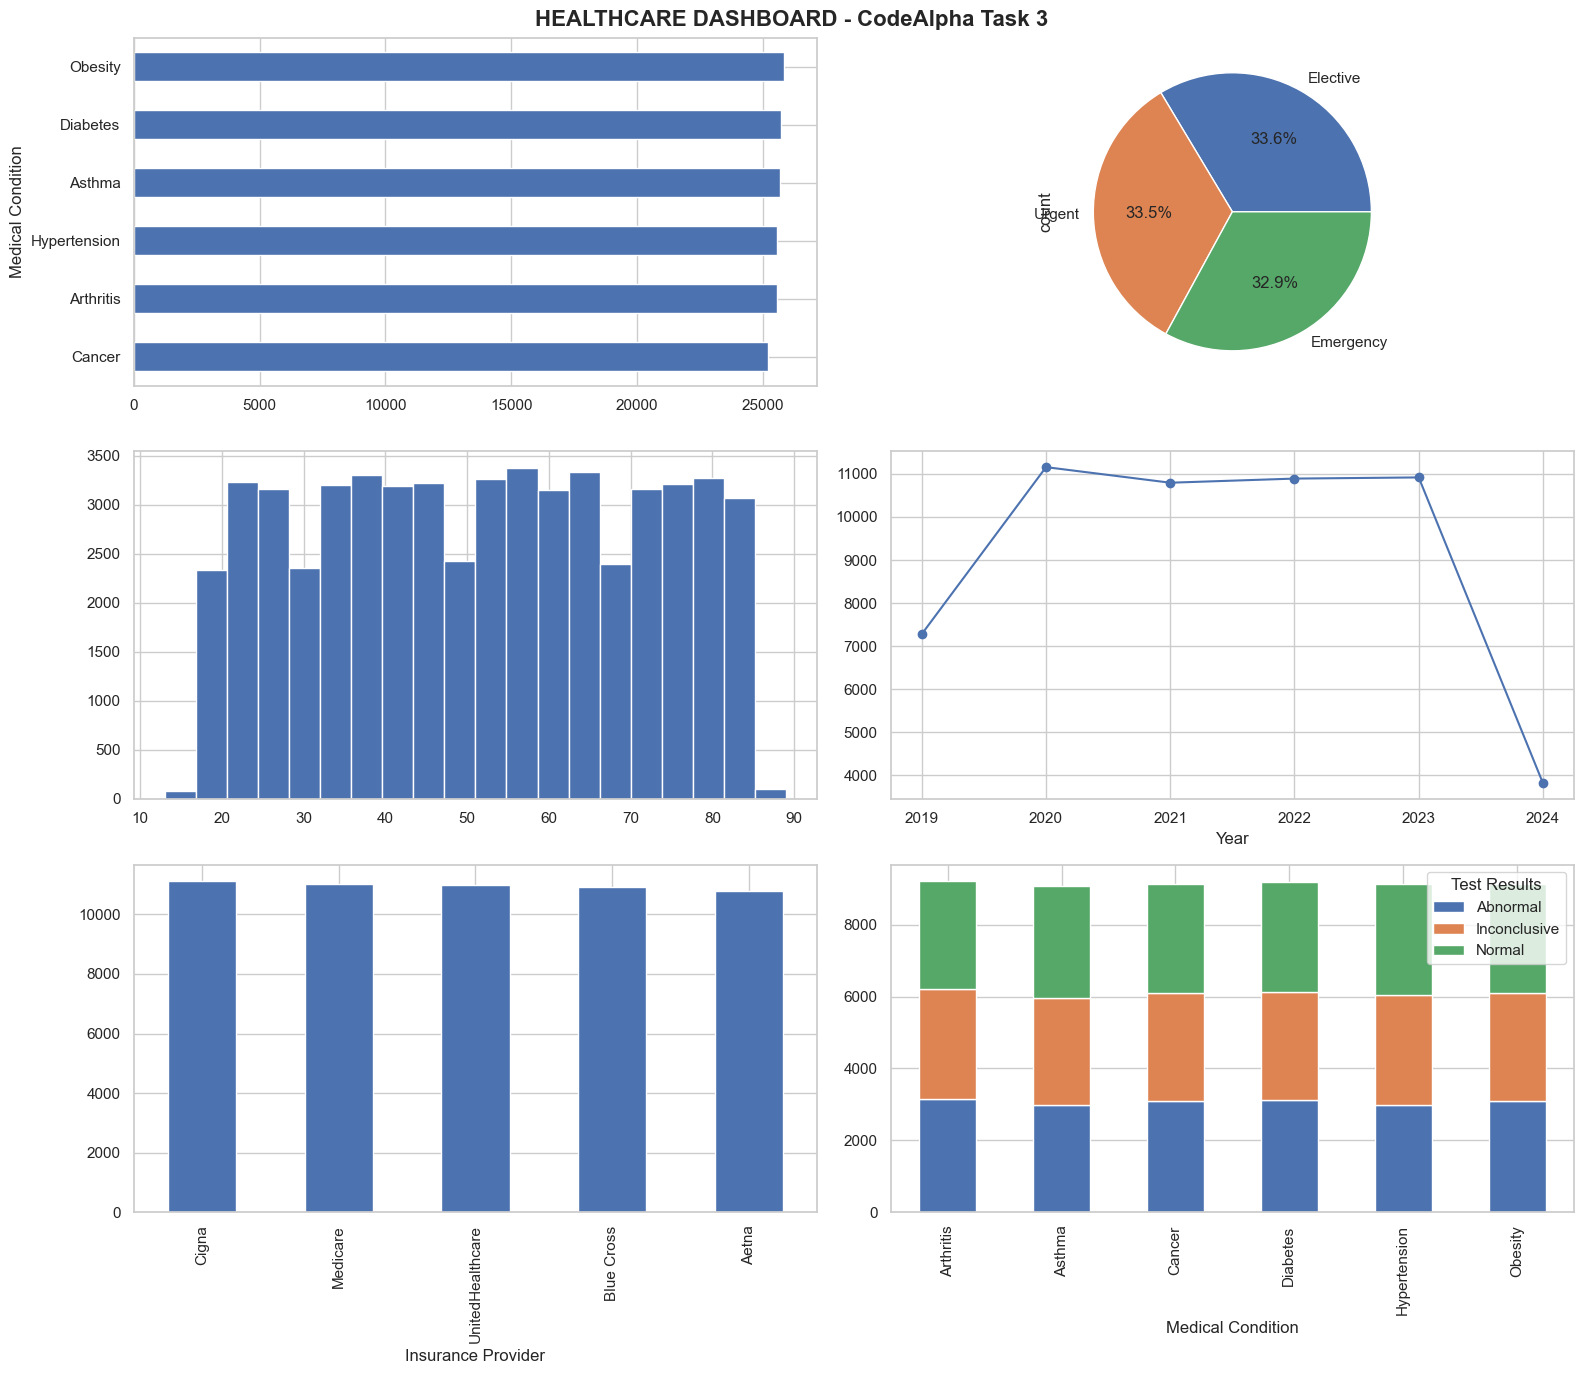

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('HEALTHCARE DASHBOARD - CodeAlpha Task 3', fontsize=16, fontweight='bold')

df.groupby('Medical Condition')['Billing Amount'].mean().sort_values().plot(kind='barh', ax=axes[0,0])
df['Admission Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0,1])
df['Age'].hist(bins=20, ax=axes[1,0])
df['Year'].value_counts().sort_index().plot(marker='o', ax=axes[1,1])
df['Insurance Provider'].value_counts().plot(kind='bar', ax=axes[2,0])
df.groupby(['Medical Condition','Test Results']).size().unstack().plot(kind='bar', stacked=True, ax=axes[2,1])

plt.tight_layout()
plt.savefig('FINAL_DASHBOARD.png', dpi=300)
plt.show()